# Transformer 详解与 PyTorch 实现

## 为什么 Transformer 如此重要？

Transformer（2017，Attention Is All You Need）彻底改变了深度学习：
- NLP: BERT、GPT、ChatGPT 都基于 Transformer
- CV: ViT、Swin Transformer 挑战 CNN
- 多模态: CLIP、DALL-E

核心创新：**自注意力机制（Self-Attention）**，替代 RNN 的递归结构，实现并行计算。

## 本课路线

1. 自注意力机制
2. 多头注意力
3. 位置编码
4. Transformer Encoder
5. Transformer Decoder（简介）
6. 完整实现与实战

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import numpy as np
import matplotlib.pyplot as plt

## 1. 自注意力机制（Self-Attention）

### 核心思想

对于序列中的每个位置，计算它与其他所有位置的关联程度（注意力），然后用这些关联度加权求和。

### 三个角色：Q、K、V

| 符号 | 名称 | 类比 |
|------|------|------|
| Q (Query) | 查询 | "我想找什么" |
| K (Key) | 键 | "我有什么特征" |
| V (Value) | 值 | "我的实际内容" |

### 计算过程

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

1. Q 和 K 做点积 → 得到注意力分数
2. 除以 $\sqrt{d_k}$ → 防止分数过大
3. softmax → 归一化为概率
4. 乘以 V → 加权求和

In [2]:
# 手动实现自注意力
torch.manual_seed(42)

seq_len = 4
d_model = 8

x = torch.randn(seq_len, d_model)
print(f"输入形状: {x.shape}  (seq_len={seq_len}, d_model={d_model})")

# 线性投影得到 Q, K, V
W_q = torch.randn(d_model, d_model) * 0.1
W_k = torch.randn(d_model, d_model) * 0.1
W_v = torch.randn(d_model, d_model) * 0.1

Q = x @ W_q   # (4, 8)
K = x @ W_k   # (4, 8)
V = x @ W_v   # (4, 8)

print(f"Q shape: {Q.shape}, K shape: {K.shape}, V shape: {V.shape}")

输入形状: torch.Size([4, 8])  (seq_len=4, d_model=8)
Q shape: torch.Size([4, 8]), K shape: torch.Size([4, 8]), V shape: torch.Size([4, 8])


In [3]:
# 步骤1: Q 和 K 做点积 → 注意力分数
scores = Q @ K.T  # (4, 4)
print(f"注意力分数 (Q @ K^T) 形状: {scores.shape}")
print(f"分数矩阵:\n{scores.numpy().round(2)}")
print()
print("scores[i][j] = 第i个位置对第j个位置的关注度")

# 步骤2: 缩放
d_k = d_model
scores_scaled = scores / math.sqrt(d_k)
print(f"\n缩放后 (除以 sqrt({d_k})={math.sqrt(d_k):.2f}):")
print(f"缩放分数:\n{scores_scaled.numpy().round(2)}")
print("缩放原因: d_k 很大时，点积结果也很大，softmax 梯度会趋近0")

注意力分数 (Q @ K^T) 形状: torch.Size([4, 4])
分数矩阵:
[[ 0.48 -0.01  0.07  0.16]
 [ 0.02  0.15 -0.11 -0.12]
 [-0.21 -0.04  0.17  0.06]
 [ 0.07  0.04  0.5   0.36]]

scores[i][j] = 第i个位置对第j个位置的关注度

缩放后 (除以 sqrt(8)=2.83):
缩放分数:
[[ 0.17 -0.01  0.02  0.06]
 [ 0.01  0.05 -0.04 -0.04]
 [-0.07 -0.01  0.06  0.02]
 [ 0.03  0.01  0.18  0.13]]
缩放原因: d_k 很大时，点积结果也很大，softmax 梯度会趋近0


In [4]:
# 步骤3: softmax 归一化
attn_weights = torch.softmax(scores_scaled, dim=-1)
print(f"注意力权重 (softmax后):\n{attn_weights.numpy().round(3)}")
print(f"\n每行和为1: {attn_weights.sum(dim=-1).numpy().round(6)}")
print("attn_weights[i][j] = 位置i对位置j的注意力权重")

# 步骤4: 加权求和
output = attn_weights @ V  # (4, 8)
print(f"\n输出形状: {output.shape}")
print("每个位置的输出 = 所有位置的 V 按注意力权重加权求和")

注意力权重 (softmax后):
[[0.278 0.233 0.24  0.248]
 [0.253 0.265 0.242 0.241]
 [0.232 0.247 0.266 0.255]
 [0.235 0.232 0.273 0.26 ]]

每行和为1: [1. 1. 1. 1.]
attn_weights[i][j] = 位置i对位置j的注意力权重

输出形状: torch.Size([4, 8])
每个位置的输出 = 所有位置的 V 按注意力权重加权求和


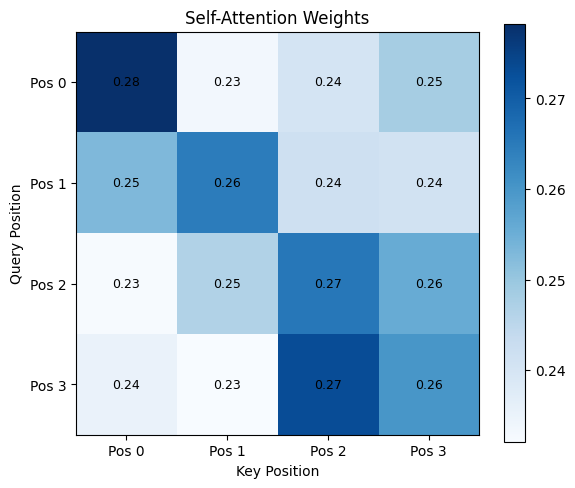

In [5]:
# 可视化注意力权重
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights.detach().numpy(), cmap='Blues')
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels([f'Pos {i}' for i in range(seq_len)])
ax.set_yticklabels([f'Pos {i}' for i in range(seq_len)])
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
ax.set_title('Self-Attention Weights')
plt.colorbar(im)
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{attn_weights[i,j].item():.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# 为什么需要缩放？
print("=== 为什么除以 sqrt(d_k)？ ===")
print()

for d_k in [8, 64, 512]:
    q = torch.randn(1, d_k)
    k = torch.randn(1, d_k)
    dot = (q @ k.T).item()
    scaled = dot / math.sqrt(d_k)
    print(f"d_k={d_k:3d}: 点积={dot:8.2f}, 缩放后={scaled:8.2f}")

print()
print("d_k 越大，点积的方差越大")
print("大方差 → softmax 输出接近 one-hot → 梯度接近0")
print("缩放使方差回归1，softmax 梯度健康")

=== 为什么除以 sqrt(d_k)？ ===

d_k=  8: 点积=    0.83, 缩放后=    0.29
d_k= 64: 点积=    7.96, 缩放后=    0.99
d_k=512: 点积=   47.07, 缩放后=    2.08

d_k 越大，点积的方差越大
大方差 → softmax 输出接近 one-hot → 梯度接近0
缩放使方差回归1，softmax 梯度健康


## 2. 多头注意力（Multi-Head Attention）

单头注意力只有一组 Q/K/V 投影，表达能力有限。

多头注意力使用多组独立的 Q/K/V 投影，让模型同时关注不同位置的不同表示子空间。

```
输入 x → 分成 h 个头
  Head 1: Q1, K1, V1 → Attention → out1
  Head 2: Q2, K2, V2 → Attention → out2
  ...
  Head h: Qh, Kh, Vh → Attention → outh
→ Concat(out1, ..., outh) → Linear → 输出
```

In [ ]:
# 手动实现多头注意力
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    
    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape
        
        # 线性投影
        Q = self.W_q(x)  # (B, S, D)
        K = self.W_k(x)
        V = self.W_v(x)
        
        # 重塑为多头: (B, S, D) -> (B, H, S, d_k)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # 注意力计算
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)  # (B, H, S, S)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attn_weights = torch.softmax(scores, dim=-1)
        attn_output = attn_weights @ V  # (B, H, S, d_k)
        
        # 合并多头: (B, H, S, d_k) -> (B, S, D)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        # 最终线性投影
        output = self.W_o(attn_output)
        return output, attn_weights

mha = MultiHeadAttention(d_model=64, num_heads=4)
x = torch.randn(2, 10, 64)  # (batch=2, seq_len=10, d_model=64)
out, weights = mha(x)

print(f"输入: {x.shape}")
print(f"输出: {out.shape}")
print(f"注意力权重: {weights.shape}")  # (2, 4, 10, 10)
print(f"\n每个头独立计算注意力，关注不同的模式")
print(f"d_model={64}, num_heads={4}, d_k={64//4}=每个头的维度")

In [ ]:
# 可视化不同头的注意力
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    im = axes[i].imshow(weights[0, i].detach().numpy(), cmap='Blues')
    axes[i].set_title(f'Head {i+1}')
    axes[i].set_xlabel('Key')
    axes[i].set_ylabel('Query')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Multi-Head Attention Weights (Sample 0)', fontsize=14)
plt.tight_layout()
plt.show()

print("不同头关注不同的位置关系")
print("有的头关注局部，有的头关注全局")

## 3. 位置编码（Positional Encoding）

自注意力本身没有位置信息（与顺序无关），需要显式注入位置信息。

原始 Transformer 使用正弦/余弦位置编码：

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]

pe_layer = PositionalEncoding(d_model=64, max_len=100)
x = torch.zeros(1, 50, 64)
x_with_pe = pe_layer(x)

print(f"输入形状: {x.shape}")
print(f"加位置编码后: {x_with_pe.shape}")
print(f"位置编码本身: {pe_layer.pe.shape}")

In [ ]:
# 可视化位置编码
pe = PositionalEncoding(d_model=128, max_len=100)
pe_matrix = pe.pe[0, :50, :].detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(pe_matrix.T, aspect='auto', cmap='RdBu')
axes[0].set_xlabel('Position')
axes[1].set_ylabel('Dimension')
axes[0].set_title('Positional Encoding Matrix')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Dimension')
plt.colorbar(im, ax=axes[0])

dims = [0, 1, 10, 50]
for d in dims:
    axes[1].plot(pe_matrix[:, d], label=f'dim {d}')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Value')
axes[1].set_title('Positional Encoding by Dimension')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("低维度: 变化快（高频），区分相邻位置")
print("高维度: 变化慢（低频），区分远距离位置")

In [ ]:
# 可学习的位置编码（更常用）
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

learn_pe = LearnablePositionalEncoding(d_model=64)
print(f"可学习位置编码参数形状: {learn_pe.pe.shape}")
print("ViT、GPT 等模型常用可学习位置编码")
print("原始 Transformer 用固定正弦位置编码")

## 4. Transformer Encoder

### 单个 Encoder 层

```
输入 x
  ↓
Multi-Head Attention → Add & Norm (残差 + LayerNorm)
  ↓
Feed-Forward Network → Add & Norm (残差 + LayerNorm)
  ↓
输出
```

关键组件：
- **残差连接（Add）**: x + Sublayer(x)，解决梯度消失
- **Layer Norm**: 对每个样本的特征维度归一化
- **FFN**: 两层全连接，中间有 ReLU/GELU

In [ ]:
# Feed-Forward Network
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        return self.net(x)

# Encoder 层
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # 自注意力 + 残差 + LayerNorm
        attn_out, _ = self.attention(x, mask)
        x = self.norm1(x + self.dropout1(attn_out))
        
        # FFN + 残差 + LayerNorm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        
        return x

encoder_layer = TransformerEncoderLayer(d_model=64, num_heads=4, d_ff=256)
x = torch.randn(2, 10, 64)
out = encoder_layer(x)
print(f"Encoder 层: 输入 {x.shape} → 输出 {out.shape}")
print("形状不变！Transformer 保持序列长度不变")

In [ ]:
# 完整 Transformer Encoder
class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

encoder = TransformerEncoder(num_layers=6, d_model=64, num_heads=4, d_ff=256)
x = torch.randn(2, 10, 64)
out = encoder(x)
print(f"6层 Encoder: 输入 {x.shape} → 输出 {out.shape}")
print(f"参数量: {sum(p.numel() for p in encoder.parameters()):,}")

## 5. Transformer 分类模型

类似 ViT 的做法：在序列前加一个 [CLS] token，用它的输出做分类。

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=64, num_heads=4,
                 num_layers=4, d_ff=256, max_len=512, dropout=0.1):
        super().__init__()
        
        # 词嵌入
        self.embedding = nn.Embedding(vocab_size, d_model)
        # 位置编码
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        # [CLS] token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        # Encoder
        self.encoder = TransformerEncoder(num_layers, d_model, num_heads, d_ff, dropout)
        # 分类头
        self.classifier = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        # 词嵌入 + 位置编码
        x = self.embedding(x)  # (B, S, D)
        x = self.pos_encoding(x)
        
        # 在序列前加 [CLS] token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # (B, 1, D)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, S+1, D)
        
        # Encoder
        x = self.encoder(x)  # (B, S+1, D)
        
        # 取 [CLS] token 的输出做分类
        cls_output = x[:, 0]  # (B, D)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)  # (B, num_classes)
        
        return logits

model = TransformerClassifier(vocab_size=1000, num_classes=3)
x = torch.randint(0, 1000, (4, 30))
out = model(x)
print(f"模型输入: {x.shape}")
print(f"模型输出: {out.shape}")
print(f"参数量: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# 训练 Transformer 分类器
torch.manual_seed(42)

vocab_size = 2000
num_classes = 4
n_samples = 1000
seq_len = 40

X = torch.randint(0, vocab_size, (n_samples, seq_len))
y = torch.randint(0, num_classes, (n_samples,))

from torch.utils.data import TensorDataset, DataLoader, random_split

full_dataset = TensorDataset(X, y)
train_set, val_set = random_split(full_dataset, [800, 200],
    generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

model = TransformerClassifier(vocab_size, num_classes, d_model=64, num_heads=4, num_layers=4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

train_losses, val_accs = [], []
for epoch in range(30):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    train_losses.append(epoch_loss / len(train_set))
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            correct += (model(X_batch).argmax(1) == y_batch).sum().item()
            total += X_batch.size(0)
    val_accs.append(correct / total)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}: loss={train_losses[-1]:.4f}, val_acc={val_accs[-1]:.4f}")

print(f"\n最终验证准确率: {val_accs[-1]:.4f}")

## 6. 因果掩码（Causal Mask）与 Decoder

Decoder 的自注意力需要**因果掩码**：每个位置只能看到它之前的位置，不能"偷看"未来。

这是语言模型（GPT）生成文本的关键。

In [ ]:
# 因果掩码
seq_len = 6
causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)

print("因果掩码 (下三角矩阵):")
print(causal_mask[0, 0].numpy().astype(int))
print()
print("1 = 可以关注，0 = 不能关注")
print("位置 i 只能看到位置 0~i（不能看未来）")
print()
print("例如:")
print("  位置0: 只看位置0")
print("  位置2: 看位置0,1,2")
print("  位置5: 看位置0,1,2,3,4,5")

In [ ]:
# 带因果掩码的注意力
mha = MultiHeadAttention(d_model=64, num_heads=4)
x = torch.randn(1, seq_len, 64)

out_no_mask, weights_no_mask = mha(x)
out_with_mask, weights_with_mask = mha(x, mask=causal_mask)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(weights_no_mask[0, 0].detach().numpy(), cmap='Blues')
axes[0].set_title('Without Mask')
axes[0].set_xlabel('Key')
axes[0].set_ylabel('Query')

im = axes[1].imshow(weights_with_mask[0, 0].detach().numpy(), cmap='Blues')
axes[1].set_title('With Causal Mask')
axes[1].set_xlabel('Key')
axes[1].set_ylabel('Query')
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

print("因果掩码后，上三角的注意力权重为0（看不到未来）")

## 7. PyTorch 内置 Transformer

In [ ]:
# PyTorch 内置的 nn.Transformer
d_model = 64
nhead = 4
num_encoder_layers = 4
num_decoder_layers = 4
dim_feedforward = 256

transformer = nn.Transformer(
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=0.1,
    batch_first=True,
)

# Encoder 输入
src = torch.randn(2, 10, d_model)
# Decoder 输入
tgt = torch.randn(2, 8, d_model)

out = transformer(src, tgt)
print(f"PyTorch nn.Transformer:")
print(f"  src: {src.shape}, tgt: {tgt.shape}")
print(f"  输出: {out.shape}")
print(f"  参数量: {sum(p.numel() for p in transformer.parameters()):,}")

In [ ]:
# 使用 nn.TransformerEncoder（更常用）
encoder_layer = nn.TransformerEncoderLayer(
    d_model=64, nhead=4, dim_feedforward=256,
    dropout=0.1, batch_first=True
)
encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)

x = torch.randn(2, 10, 64)
out = encoder(x)
print(f"nn.TransformerEncoder: {x.shape} → {out.shape}")
print("\n实际项目中，推荐用 PyTorch 内置的 Transformer 层")
print("比自己实现更高效、更稳定")

## 8. Transformer 架构全景

In [ ]:
print("=== Transformer 架构总结 ===")
print()
print("Encoder (BERT, ViT 等):")
print("  Input → Embedding + PosEnc → [EncoderLayer x N] → Output")
print("  每个 EncoderLayer:")
print("    Multi-Head Attention → Add & Norm")
print("    Feed-Forward Network → Add & Norm")
print()
print("Decoder (GPT 等):")
print("  Input → Embedding + PosEnc → [DecoderLayer x N] → Output")
print("  每个 DecoderLayer:")
print("    Masked Multi-Head Attention → Add & Norm  (因果掩码)")
print("    Cross-Attention → Add & Norm              (关注 Encoder 输出)")
print("    Feed-Forward Network → Add & Norm")
print()
print("Encoder-Decoder (翻译, T5 等):")
print("  Encoder 处理源序列 → Decoder 结合源信息生成目标序列")
print()
print("=== 著名模型 ===")
print()
print("Encoder-Only:")
print("  BERT:   双向注意力，理解任务（分类、NER）")
print("  ViT:    图像分块，用 Transformer 做图像分类")
print()
print("Decoder-Only:")
print("  GPT:    因果注意力，生成任务（文本生成）")
print("  LLaMA:  开源大语言模型")
print()
print("Encoder-Decoder:")
print("  T5:     文本到文本的统一框架")
print("  BART:   去噪自编码器")

In [ ]:
# Transformer vs RNN 对比
print("=== Transformer vs RNN ===")
print()
print("| 特性       | RNN/LSTM        | Transformer     |")
print("|-----------|-----------------|-----------------|")
print("| 并行性     | 串行（逐步处理） | 完全并行         |")
print("| 长程依赖   | 梯度消失问题     | 直接连接任意位置  |")
print("| 计算复杂度 | O(n)            | O(n^2)          |")
print("| 位置信息   | 天然有序         | 需要位置编码     |")
print("| 参数量     | 较少            | 较多            |")
print()
print("Transformer 优势: 并行训练快，长程依赖好")
print("Transformer 劣势: 序列长度 O(n^2) 复杂度，需要更多数据")

---
## 总结

### Transformer 核心公式

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### 关键组件

| 组件 | 作用 |
|------|------|
| Multi-Head Attention | 多角度关注序列内部关系 |
| Positional Encoding | 注入位置信息 |
| Feed-Forward Network | 非线性变换 |
| Residual + LayerNorm | 稳定训练 |
| Causal Mask | 防止看到未来（Decoder） |

### 模型选择

| 任务 | 模型类型 | 代表 |
|------|----------|------|
| 分类/理解 | Encoder-Only | BERT, ViT |
| 生成 | Decoder-Only | GPT, LLaMA |
| 翻译/转换 | Encoder-Decoder | T5, BART |

### 训练技巧
- 使用 AdamW + Warmup + Cosine Decay
- 梯度裁剪
- Dropout 正则化
- 大模型需要大数据